<a href="https://colab.research.google.com/github/mohitpreet9435-gif/northstar-python-risk-intelligence/blob/main/06_Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [19]:
# Import datasets from GitHub

customers = pd.read_csv(
    "https://raw.githubusercontent.com/mohitpreet9435-gif/Dataset/main/customers.csv"
)

deliveries = pd.read_csv(
    "https://raw.githubusercontent.com/mohitpreet9435-gif/Dataset/main/deliveries.csv"
)

complaints = pd.read_csv(
    "https://raw.githubusercontent.com/mohitpreet9435-gif/Dataset/main/complaints.csv"
)

drivers = pd.read_csv(
    "https://raw.githubusercontent.com/mohitpreet9435-gif/Dataset/main/drivers.csv"
)

incidents = pd.read_csv(
    "https://raw.githubusercontent.com/mohitpreet9435-gif/Dataset/main/incidents.csv"
)

In [20]:
# Preview deliveries dataset

deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [21]:
# Check missing values

print(deliveries.isnull().sum())

delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64


In [22]:
# Fill missing customer ratings

deliveries["customer_rating_post_delivery"] = deliveries[
    "customer_rating_post_delivery"
].fillna(
    deliveries["customer_rating_post_delivery"].mean()
)

# Fill missing completion timestamps

deliveries["delivery_completed_at"] = deliveries[
    "delivery_completed_at"
].fillna("Unknown")

In [23]:
# Create operational inefficiency score

deliveries["inefficiency_score"] = (
    deliveries["manual_route_override_count"] * 0.4
    +
    deliveries["route_distance_km"] * 0.2
    +
    deliveries["fuel_or_charge_cost"] * 0.3
    +
    deliveries["proof_of_completion_missing"] * 0.1
)

# Highest inefficiency deliveries

highest_inefficiency = deliveries[
    ["delivery_id", "inefficiency_score"]
].sort_values(
    by="inefficiency_score",
    ascending=False
)

highest_inefficiency.head(10)

,delivery_id,inefficiency_score
896,DL00897,16.357
805,DL00806,16.203
428,DL00429,16.153
54,DL00055,15.774
286,DL00287,15.366
89,DL00090,15.232
118,DL00119,15.201
143,DL00144,15.010
671,DL00672,14.997
379,DL00380,14.579


VISUALISATION 1 — Inefficiency Score Distribution

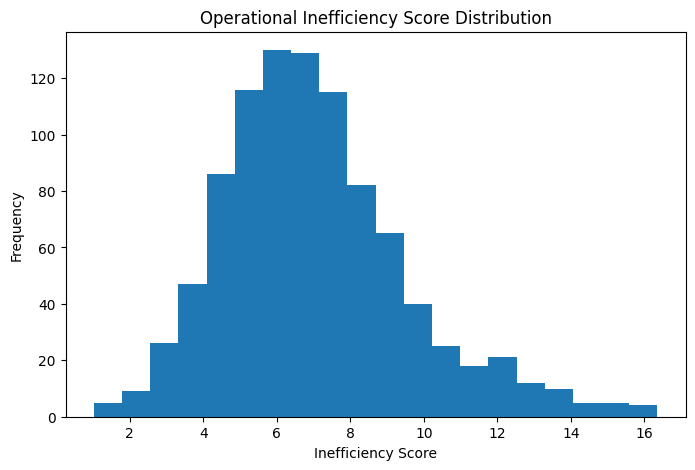

In [24]:
# Operational inefficiency distribution

plt.figure(figsize=(8,5))

plt.hist(
    deliveries["inefficiency_score"],
    bins=20
)

plt.title("Operational Inefficiency Score Distribution")

plt.xlabel("Inefficiency Score")

plt.ylabel("Frequency")

plt.show()

ANALYSIS 2 — High-Risk Delivery Detection

In [25]:
# Create high-risk delivery score

deliveries["high_risk_score"] = (
    deliveries["manual_route_override_count"] * 2
    +
    deliveries["proof_of_completion_missing"] * 3
    +
    np.where(deliveries["delivery_status"] == "Failed", 5, 0)
    +
    np.where(deliveries["delivery_status"] == "Delayed", 3, 0)
)

# Top risky deliveries

high_risk_deliveries = deliveries[
    ["delivery_id", "high_risk_score", "delivery_status"]
].sort_values(
    by="high_risk_score",
    ascending=False
)

high_risk_deliveries.head(10)

,delivery_id,high_risk_score,delivery_status
921,DL00922,16,Delayed
54,DL00055,16,Delayed
880,DL00881,16,Delayed
305,DL00306,14,Delayed
514,DL00515,14,Failed
504,DL00505,14,Failed
40,DL00041,14,Failed
730,DL00731,14,Failed
472,DL00473,14,OnTime
788,DL00789,14,Failed


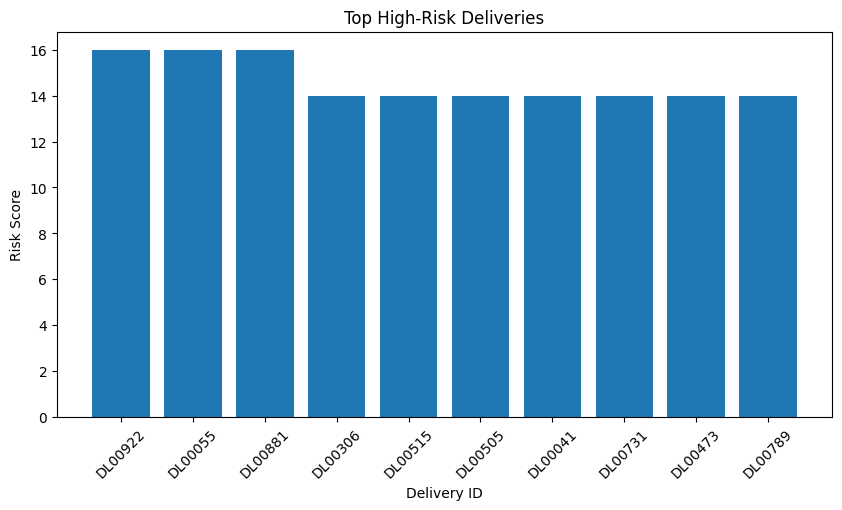

In [26]:
# Top high-risk deliveries chart

top_risk = high_risk_deliveries.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_risk["delivery_id"],
    top_risk["high_risk_score"]
)

plt.title("Top High-Risk Deliveries")

plt.xlabel("Delivery ID")

plt.ylabel("Risk Score")

plt.xticks(rotation=45)

plt.show()

ANALYSIS 3 — Driver Risk Profiling

In [27]:
# Driver risk profiling

driver_risk = deliveries.groupby("driver_id").agg({
    "manual_route_override_count": "mean",
    "customer_rating_post_delivery": "mean",
    "fuel_or_charge_cost": "mean"
}).reset_index()

# Create driver risk score

driver_risk["driver_risk_score"] = (
    driver_risk["manual_route_override_count"] * 0.5
    +
    (5 - driver_risk["customer_rating_post_delivery"]) * 0.4
    +
    driver_risk["fuel_or_charge_cost"] * 0.1
)

# Highest risk drivers

driver_risk.sort_values(
    by="driver_risk_score",
    ascending=False
).head(10)

,driver_id,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost,driver_risk_score
111,D112,4.500000,3.415000,13.050000,4.189000
84,D085,2.000000,3.417500,17.042500,3.337250
146,D147,1.000000,3.100000,19.955000,3.255500
126,D127,2.833333,4.105000,14.135000,3.188167
20,D021,2.500000,3.105000,11.675000,3.175500
123,D124,2.000000,3.412500,15.132500,3.148250
68,D069,2.000000,3.938571,16.577143,3.082286
83,D084,1.250000,3.535000,18.230000,3.034000
129,D130,2.000000,3.806835,15.270000,3.004266
167,D168,1.000000,3.650000,19.154000,2.955400


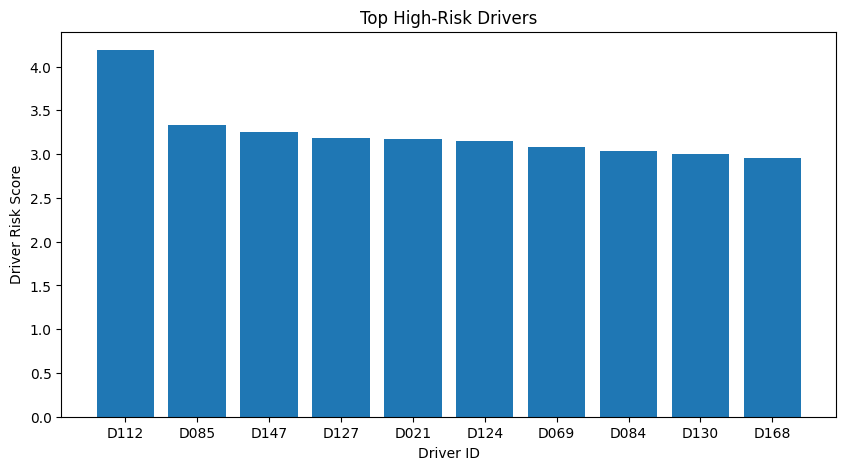

In [28]:
# Driver risk chart

top_drivers = driver_risk.sort_values(
    by="driver_risk_score",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_drivers["driver_id"],
    top_drivers["driver_risk_score"]
)

plt.title("Top High-Risk Drivers")

plt.xlabel("Driver ID")

plt.ylabel("Driver Risk Score")

plt.show()

ANALYSIS 4 — Hub Risk Analysis

In [29]:
# Hub operational risk analysis

hub_risk = deliveries.groupby("hub_id").agg({
    "manual_route_override_count": "mean",
    "fuel_or_charge_cost": "mean",
    "proof_of_completion_missing": "sum"
}).reset_index()

# Create hub risk score

hub_risk["hub_risk_score"] = (
    hub_risk["manual_route_override_count"] * 0.4
    +
    hub_risk["fuel_or_charge_cost"] * 0.4
    +
    hub_risk["proof_of_completion_missing"] * 0.2
)

# Highest risk hubs

hub_risk.sort_values(
    by="hub_risk_score",
    ascending=False
)

,hub_id,manual_route_override_count,fuel_or_charge_cost,proof_of_completion_missing,hub_risk_score
4,H05,0.947826,13.686000,10,7.853530
5,H06,0.913462,13.319231,10,7.693077
6,H07,1.052174,12.922087,9,7.389704
2,H03,0.890756,12.744202,9,7.253983
7,H08,1.109375,11.708203,10,7.127031
3,H04,0.874016,13.167008,7,7.016409
1,H02,0.915094,12.565000,8,6.992038
0,H01,1.029412,12.755809,6,6.714088


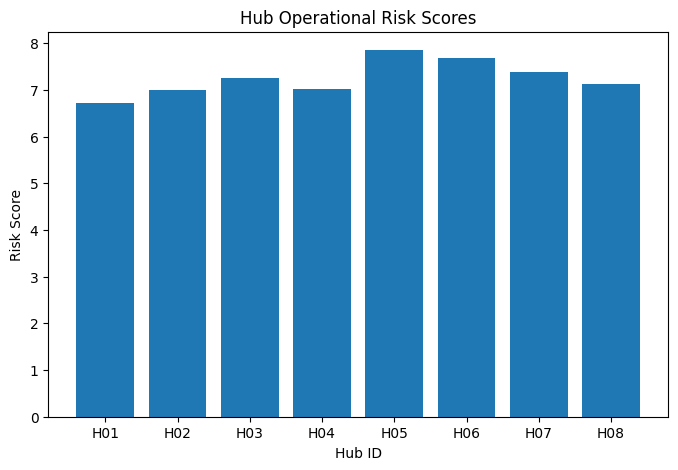

In [30]:
# Hub risk analysis chart

plt.figure(figsize=(8,5))

plt.bar(
    hub_risk["hub_id"],
    hub_risk["hub_risk_score"]
)

plt.title("Hub Operational Risk Scores")

plt.xlabel("Hub ID")

plt.ylabel("Risk Score")

plt.show()

ANALYSIS 5 — Complaint Behaviour Analysis

In [31]:
# Merge deliveries with complaints

complaint_analysis = pd.merge(
    deliveries,
    complaints,
    on="order_id",
    how="inner"
)

# Complaint operational patterns

complaint_patterns = complaint_analysis.groupby(
    "delivery_status"
).agg({
    "complaint_id": "count",
    "manual_route_override_count": "mean",
    "fuel_or_charge_cost": "mean"
}).reset_index()

complaint_patterns

,delivery_status,complaint_id,manual_route_override_count,fuel_or_charge_cost
0,Delayed,48,1.145833,12.967083
1,Failed,35,1.057143,12.349429
2,OnTime,149,0.791946,12.823826


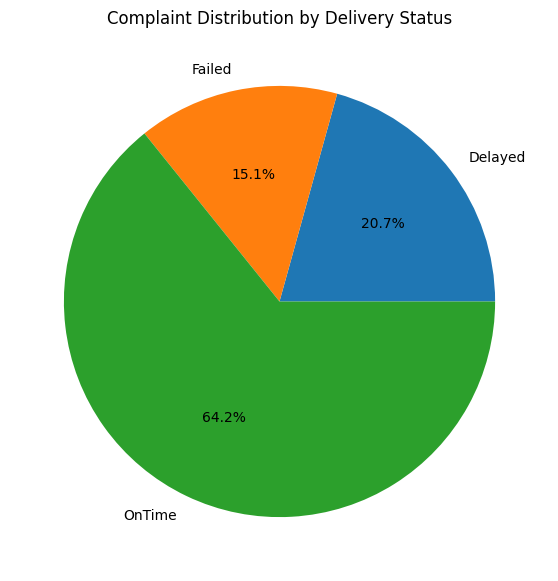

In [32]:
# Complaint distribution by delivery status

plt.figure(figsize=(7,7))

plt.pie(
    complaint_patterns["complaint_id"],
    labels=complaint_patterns["delivery_status"],
    autopct='%1.1f%%'
)

plt.title("Complaint Distribution by Delivery Status")

plt.show()

ANALYSIS 6 — Anomaly Detection using Isolation Forest

In [33]:
# Select operational features

features = deliveries[
    [
        "route_distance_km",
        "manual_route_override_count",
        "fuel_or_charge_cost",
        "customer_rating_post_delivery"
    ]
]

# Standardise features

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

# Isolation Forest model

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

deliveries["anomaly"] = model.fit_predict(
    scaled_features
)

# Convert anomaly labels

deliveries["anomaly"] = deliveries["anomaly"].map({
    1: 0,
    -1: 1
})

# Display anomalies

anomalies = deliveries[
    deliveries["anomaly"] == 1
]

anomalies.head(10)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,inefficiency_score,high_risk_score,anomaly
16,DL00017,O01249,D002,V008,H05,2024-08-25 18:26:00,2024-08-26 03:05:42.086626,Delayed,20.79,0,0,1.00,15.62,8.844,3,1
20,DL00021,O00250,D117,V081,H08,2025-04-24 14:20:00,2025-04-25 11:20:52.916514,OnTime,9.77,4,0,4.07,6.43,5.483,8,1
22,DL00023,O00768,D046,V021,H08,2025-06-12 01:16:00,2025-06-12 02:37:11.392658,OnTime,4.29,1,0,5.00,2.50,2.008,2,1
51,DL00052,O00554,D168,V020,H08,2025-05-06 10:37:00,2025-05-06 20:57:25.303009,Delayed,26.38,1,1,2.52,24.54,13.138,8,1
54,DL00055,O00819,D069,V018,H04,2025-04-28 21:37:00,2025-04-29 04:45:04.624638,Delayed,35.07,5,1,2.78,22.20,15.774,16,1
56,DL00057,O00921,D141,V077,H04,2024-12-09 10:53:00,2024-12-09 20:18:39.821307,Failed,10.91,0,0,1.22,6.59,4.159,5,1
58,DL00059,O00521,D027,V088,H05,2025-11-26 14:07:00,2025-11-26 18:49:47.422787,Delayed,36.28,3,0,3.11,17.45,13.691,9,1
82,DL00083,O00451,D053,V043,H05,2025-02-15 18:28:00,2025-02-16 13:33:28.440507,Delayed,2.13,0,0,1.44,11.27,3.807,3,1
84,DL00085,O00160,D127,V032,H06,2024-08-20 19:18:00,Unknown,OnTime,9.49,5,0,3.85,16.32,8.794,10,1
89,DL00090,O01097,D027,V065,H04,2024-07-14 23:21:00,2024-07-15 09:00:31.809183,OnTime,33.86,3,0,4.76,24.20,15.232,6,1


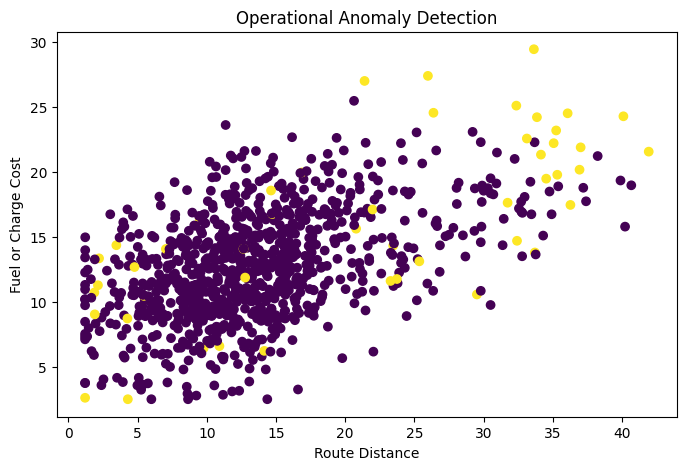

In [34]:
# Operational anomaly scatter plot

plt.figure(figsize=(8,5))

plt.scatter(
    deliveries["route_distance_km"],
    deliveries["fuel_or_charge_cost"],
    c=deliveries["anomaly"]
)

plt.title("Operational Anomaly Detection")

plt.xlabel("Route Distance")

plt.ylabel("Fuel or Charge Cost")

plt.show()

In [35]:
# Export anomalies to CSV

anomalies.to_csv(
    "operational_anomalies.csv",
    index=False
)

print("Operational anomaly export completed.")

Operational anomaly export completed.
